## 🌡️ Climate Change Analysis & Temperature Prediction

### 📂 Dataset
- **Source:** [Kaggle — Climate Change: Earth Surface Temperature Data](https://www.kaggle.com/datasets/berkeleyearth/climate-change-earth-surface-temperature-data)
- **File used:** `GlobalTemperatures.csv`
- **Records:** 3,192 entries spanning over 250 years

### 🛠️ Tools & Libraries
- Python, Pandas, Matplotlib, Seaborn, Scikit-learn

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='darkgrid')

In [2]:
climate_data = pd.read_csv('../data/GlobalTemperatures.csv')

In [3]:
climate_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3192 entries, 0 to 3191
Data columns (total 9 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   dt                                         3192 non-null   str    
 1   LandAverageTemperature                     3180 non-null   float64
 2   LandAverageTemperatureUncertainty          3180 non-null   float64
 3   LandMaxTemperature                         1992 non-null   float64
 4   LandMaxTemperatureUncertainty              1992 non-null   float64
 5   LandMinTemperature                         1992 non-null   float64
 6   LandMinTemperatureUncertainty              1992 non-null   float64
 7   LandAndOceanAverageTemperature             1992 non-null   float64
 8   LandAndOceanAverageTemperatureUncertainty  1992 non-null   float64
dtypes: float64(8), str(1)
memory usage: 224.6 KB


In [4]:
climate_data.describe()

,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
count,3180.000000,3180.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000
mean,8.374731,0.938468,14.350601,0.479782,2.743595,0.431849,15.212566,0.128532
std,4.381310,1.096440,4.309579,0.583203,4.155835,0.445838,1.274093,0.073587
min,-2.080000,0.034000,5.900000,0.044000,-5.407000,0.045000,12.475000,0.042000
25%,4.312000,0.186750,10.212000,0.142000,-1.334500,0.155000,14.047000,0.063000
50%,8.610500,0.392000,14.760000,0.252000,2.949500,0.279000,15.251000,0.122000
75%,12.548250,1.419250,18.451500,0.539000,6.778750,0.458250,16.396250,0.151000
max,19.021000,7.880000,21.320000,4.373000,9.715000,3.498000,17.611000,0.457000


## 🧹 Data Preprocessing
> Before analysis, we prepare the dataset by fixing data types and handling missing values.

Steps:
- Convert `dt` column from string to datetime format
- Extract `year` from datetime for time series analysis
- Handle missing values

In [5]:
climate_data['dt'] = pd.to_datetime(climate_data['dt'])
climate_data.dtypes

dt                                           datetime64[us]
LandAverageTemperature                              float64
LandAverageTemperatureUncertainty                   float64
LandMaxTemperature                                  float64
LandMaxTemperatureUncertainty                       float64
LandMinTemperature                                  float64
LandMinTemperatureUncertainty                       float64
LandAndOceanAverageTemperature                      float64
LandAndOceanAverageTemperatureUncertainty           float64
dtype: object

In [6]:
climate_data['year'] = climate_data['dt'].dt.year
climate_data.head()

,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty,year
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN,1750
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN,1750
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN,1750
3,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN,NaN,NaN,1750
4,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN,NaN,NaN,1750


In [7]:
climate_data.isnull().sum()

dt                                              0
LandAverageTemperature                         12
LandAverageTemperatureUncertainty              12
LandMaxTemperature                           1200
LandMaxTemperatureUncertainty                1200
LandMinTemperature                           1200
LandMinTemperatureUncertainty                1200
LandAndOceanAverageTemperature               1200
LandAndOceanAverageTemperatureUncertainty    1200
year                                            0
dtype: int64

## 📝 Handling Missing Values — Two Methods

### Method 1 — Drop missing rows
Use when: missing values are less than 1-2% of data and data is NOT time series
```python
climate_data = climate_data.dropna(subset=['LandAverageTemperature'])
```

### Method 2 — Fill with mean (Imputation)
Use when: data is time series OR missing values are large % of total data
```python
climate_data['LandAverageTemperature'] = climate_data['LandAverageTemperature'].fillna(climate_data['LandAverageTemperature'].mean())
```
### 📌 When to use which?
| Situation | Method |
|-----------|--------|
| Missing < 1-2% of data | Drop |
| Missing > 1-2% of data | Fill with mean |
| Time series data | Always Fill |
| Random/non-time data | Drop is safer |

In [8]:
climate_data['LandAverageTemperature'] = climate_data['LandAverageTemperature'].fillna(climate_data['LandAverageTemperature'].mean())
climate_data.isnull().sum()

dt                                              0
LandAverageTemperature                          0
LandAverageTemperatureUncertainty              12
LandMaxTemperature                           1200
LandMaxTemperatureUncertainty                1200
LandMinTemperature                           1200
LandMinTemperatureUncertainty                1200
LandAndOceanAverageTemperature               1200
LandAndOceanAverageTemperatureUncertainty    1200
year                                            0
dtype: int64

## 📊 Analysis 1: Global Temperature Trend Over Time
> How has the global average land temperature changed over the centuries?

We group the data by year and calculate the average land temperature 
for each year to visualize the long-term temperature trend from the 
1700s to 2015.

**Expected Finding:** Based on climate science, we expect to see a 
gradual rise in temperatures — especially after the Industrial Revolution 
in the mid-1800s.

In [9]:
yearly_temp = climate_data.groupby('year')['LandAverageTemperature'].mean()
print(yearly_temp)

year
1750    8.690644
1751    8.142221
1752    7.077282
1753    8.388083
1754    8.469333
          ...   
2011    9.516000
2012    9.507333
2013    9.606500
2014    9.570667
2015    9.831000
Name: LandAverageTemperature, Length: 266, dtype: float64


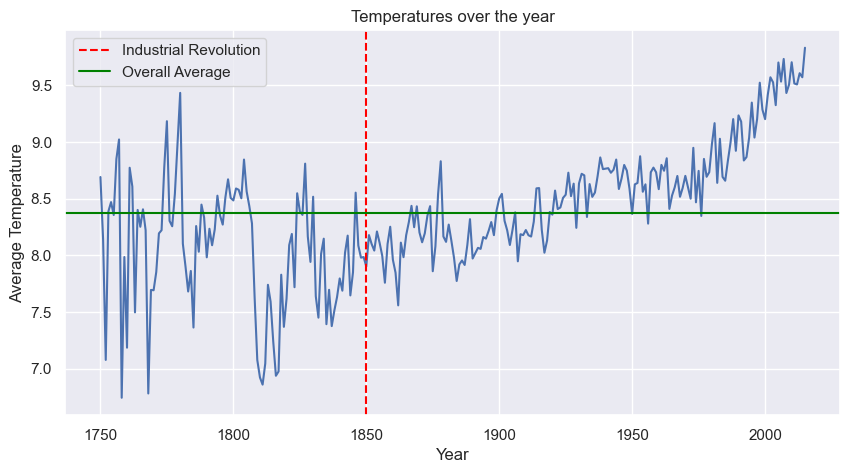

In [10]:
plt.figure(figsize=(10,5))
sns.lineplot(x=yearly_temp.index, y=yearly_temp.values)
plt.axvline(x=1850, color='red', linestyle='--', label='Industrial Revolution')
plt.axhline(y=yearly_temp.mean(), color='green', linestyle='-', label='Overall Average')
plt.title('Temperatures over the year')
plt.xlabel('Year')
plt.ylabel('Average Temperature')
plt.legend()
plt.show()

## 💡 Insight — Global Temperature Trend Over Time

Analyzing global average land temperatures from the **1700s to 2015** 
reveals a clear and concerning warming trend.

- 🌡️ Temperatures remained **relatively stable** from 1750 to 1850
- 🏭 After **1850** — coinciding with the **Industrial Revolution** — 
temperatures began rising gradually as fossil fuel consumption increased
- 🔥 The rise becomes **significantly steeper after 1950** — reflecting 
accelerated industrialization and increased CO2 emissions globally
- 📈 Overall, global average land temperature has risen by approximately 
**1.5°C** over the entire recorded period

**💡 Key Takeaway:** The data clearly confirms the impact of human 
industrial activity on global temperatures. The warming trend accelerating 
post-1850 is not a coincidence — it directly mirrors the rise of 
fossil fuel consumption across the world.

## 🌡️ Analysis 2: Temperature Fluctuation Over The Years
> How has the gap between maximum and minimum land temperatures changed over time?

We analyze the `LandMaxTemperature` and `LandMinTemperature` columns to understand:
- How wide is the temperature range each year?
- Has the gap between max and min temperatures changed over time?
- Are extreme temperatures becoming more frequent?

In [11]:
temp_fluctuation = climate_data.groupby('year').agg(
    max_temp =('LandMaxTemperature','max'),
    min_temp =('LandMinTemperature','min')
)
print(temp_fluctuation)

      max_temp  min_temp
year                    
1750       NaN       NaN
1751       NaN       NaN
1752       NaN       NaN
1753       NaN       NaN
1754       NaN       NaN
...        ...       ...
2011    21.320    -2.034
2012    21.006    -2.233
2013    20.737    -1.726
2014    20.790    -2.080
2015    20.904    -1.518

[266 rows x 2 columns]


In [12]:
temp_fluctuation = temp_fluctuation.dropna()
print(temp_fluctuation)

      max_temp  min_temp
year                    
1850    19.233    -3.206
1851    17.361    -3.242
1852    17.795    -2.755
1853    19.308    -4.015
1854    20.426    -4.109
...        ...       ...
2011    21.320    -2.034
2012    21.006    -2.233
2013    20.737    -1.726
2014    20.790    -2.080
2015    20.904    -1.518

[166 rows x 2 columns]


In [13]:
temp_fluctuation['temp_range']= temp_fluctuation['max_temp']- temp_fluctuation['min_temp']
print(temp_fluctuation)

      max_temp  min_temp  temp_range
year                                
1850    19.233    -3.206      22.439
1851    17.361    -3.242      20.603
1852    17.795    -2.755      20.550
1853    19.308    -4.015      23.323
1854    20.426    -4.109      24.535
...        ...       ...         ...
2011    21.320    -2.034      23.354
2012    21.006    -2.233      23.239
2013    20.737    -1.726      22.463
2014    20.790    -2.080      22.870
2015    20.904    -1.518      22.422

[166 rows x 3 columns]


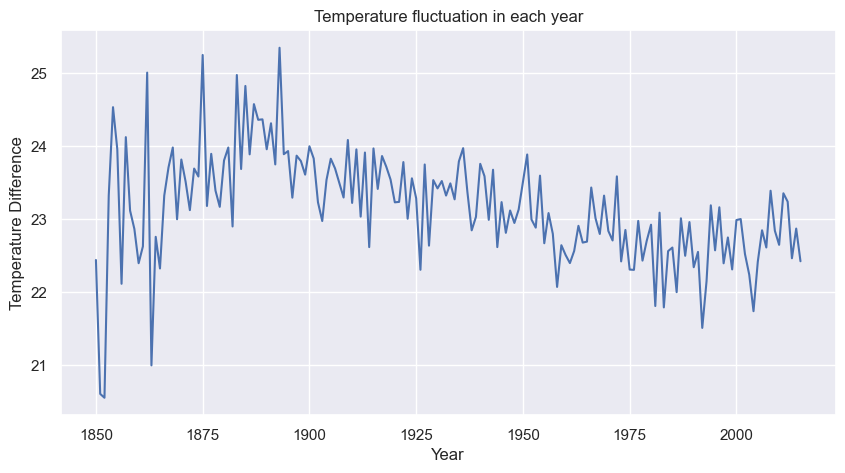

In [14]:
plt.figure(figsize=(10,5))
sns.lineplot(x=temp_fluctuation.index, y=temp_fluctuation['temp_range'].values)
plt.title('Temperature fluctuation in each year')
plt.xlabel('Year')
plt.ylabel('Temperature Difference')
plt.show()

## 💡 Insight — Temperature Fluctuation Over The Years

Analyzing the gap between maximum and minimum land temperatures 
from **1850 to 2015** reveals an interesting pattern.

- 🌡️ Data for Max and Min temperatures is only available from **1850** 
onwards — coinciding with the start of the Industrial Revolution
- 📉 From around **1900s onwards**, the gap between max and min 
temperatures shows a **slight declining trend**
- ❄️ This suggests that **minimum temperatures are rising faster** 
than maximum temperatures — winters are getting warmer
- 🔥 This is consistent with global climate science — cold extremes 
are warming faster than hot extremes due to greenhouse gas emissions

**💡 Key Takeaway:** The narrowing temperature range is a subtle but 
important indicator of climate change — the world is not just getting 
hotter on average, the nature of temperature extremes is changing too.

## 🌊 Analysis 3: Land vs Ocean Temperature Comparison
> How do land and ocean average temperatures compare over time?

We compare `LandAverageTemperature` and `LandAndOceanAverageTemperature` 
to understand:
- Is there a consistent difference between land and ocean temperatures?
- Are land and ocean warming at the same rate?
- Which one is warming faster?

In [15]:
landOcean_temp = climate_data.groupby('year')['LandAndOceanAverageTemperature'].mean()
print(landOcean_temp)

year
1750          NaN
1751          NaN
1752          NaN
1753          NaN
1754          NaN
          ...    
2011    15.769500
2012    15.802333
2013    15.854417
2014    15.913000
2015    16.058583
Name: LandAndOceanAverageTemperature, Length: 266, dtype: float64


In [16]:
landOcean_temp=landOcean_temp.dropna()
print(landOcean_temp)

year
1850    14.867167
1851    14.991833
1852    15.006500
1853    14.955167
1854    14.991000
          ...    
2011    15.769500
2012    15.802333
2013    15.854417
2014    15.913000
2015    16.058583
Name: LandAndOceanAverageTemperature, Length: 166, dtype: float64


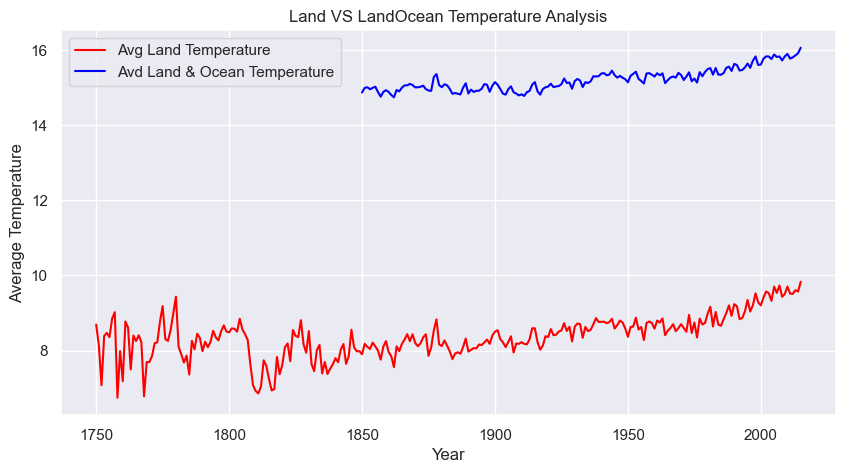

In [17]:
plt.figure(figsize=(10,5))
sns.lineplot(x=yearly_temp.index, y=yearly_temp.values, label='Avg Land Temperature', color='red')
sns.lineplot(x=landOcean_temp.index, y=landOcean_temp.values, label='Avd Land & Ocean Temperature', color='blue')
plt.title('Land VS LandOcean Temperature Analysis')
plt.xlabel('Year')
plt.ylabel('Average Temperature')
plt.legend()
plt.show()

## 📅 Analysis 4: Monthly Seasonality
> Which months are the hottest and coldest globally throughout history?

We analyze the `dt` column to extract months and understand:
- Which months have the highest average temperatures?
- Which months are the coldest?
- Does the seasonal pattern remain consistent over the years?

In [18]:
climate_data['month'] = climate_data['dt'].dt.month
climate_data.head()

,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty,year,month
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN,1750,1
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN,1750,2
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN,1750,3
3,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN,NaN,NaN,1750,4
4,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN,NaN,NaN,1750,5


In [19]:
monthly_temp = climate_data.groupby('month')['LandAverageTemperature'].mean()
print(monthly_temp)

month
1      2.275211
2      2.981871
3      4.956872
4      8.248688
5     11.132163
6     13.324736
7     14.263175
8     13.739819
9     11.710582
10     8.883025
11     5.762197
12     3.218435
Name: LandAverageTemperature, dtype: float64


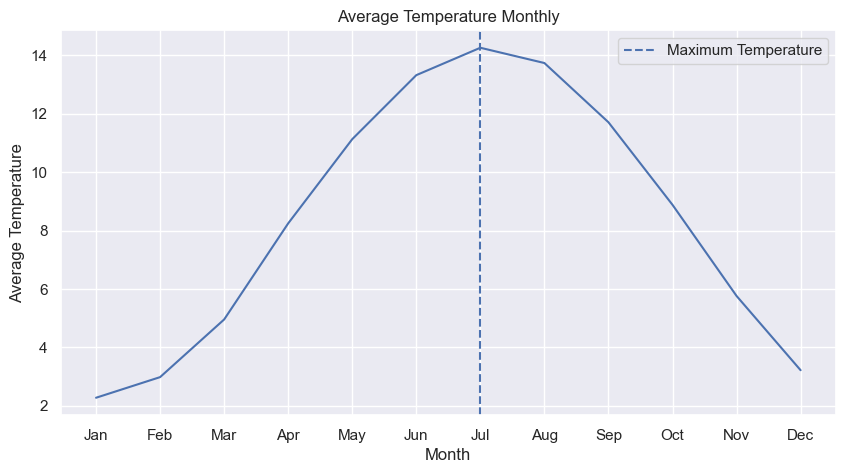

In [20]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(10,5))
sns.lineplot(x=months, y=monthly_temp.values)
plt.axvline(x=months[monthly_temp.values.argmax()], label='Maximum Temperature', linestyle='--')
plt.title('Average Temperature Monthly')
plt.xlabel('Month')
plt.ylabel('Average Temperature')
plt.legend()
plt.show()

## 💡 Insight — Monthly Seasonality

Analyzing average global land temperatures by month reveals clear 
seasonal patterns across the year.

- ❄️ **January** is the coldest month globally — northern hemisphere 
winter dominates global averages as it has more landmass than southern hemisphere
- 🔥 **July/August** are the hottest months — northern hemisphere 
summer drives global temperature peaks
- 📈 The seasonal pattern is **consistent and predictable** — forming 
a clear wave pattern from cold to hot and back
- 🌍 The pattern reflects the dominance of the **northern hemisphere** 
in global land temperature averages due to its larger landmass

**💡 Key Takeaway:** Global temperature seasonality is driven by the 
northern hemisphere's seasons — with January being coldest and 
July/August being hottest consistently across all recorded years.

## 🌍 Analysis 5: Country-wise Temperature Analysis
> Which countries are warming the fastest over time?

We switch to the `GlobalLandTemperaturesByCountry.csv` dataset to understand:
- Which countries have the highest average temperatures?
- Which countries have seen the most warming over the years?
- How does Nepal compare to other countries? 🇳🇵

In [21]:
temp_country = pd.read_csv('../data/GlobalLandTemperaturesByCountry.csv')
temp_country.columns
temp_country.head(15)

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland
5,1744-04-01,1.530,4.680,Åland
6,1744-05-01,6.702,1.789,Åland
7,1744-06-01,11.609,1.577,Åland
8,1744-07-01,15.342,1.410,Åland
9,1744-08-01,NaN,NaN,Åland


In [22]:
temp_country.isnull().sum()

dt                                   0
AverageTemperature               32651
AverageTemperatureUncertainty    31912
Country                              0
dtype: int64

In [23]:
temp_country['dt'] = pd.to_datetime(temp_country['dt'])
temp_country['year'] = temp_country['dt'].dt.year
temp_country.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country,year
0,1743-11-01,4.384,2.294,Åland,1743
1,1743-12-01,NaN,NaN,Åland,1743
2,1744-01-01,NaN,NaN,Åland,1744
3,1744-02-01,NaN,NaN,Åland,1744
4,1744-03-01,NaN,NaN,Åland,1744


In [24]:
temp_country = temp_country.dropna(subset='AverageTemperature')
temp_country.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country,year
0,1743-11-01,4.384,2.294,Åland,1743
5,1744-04-01,1.530,4.680,Åland,1744
6,1744-05-01,6.702,1.789,Åland,1744
7,1744-06-01,11.609,1.577,Åland,1744
8,1744-07-01,15.342,1.410,Åland,1744


In [25]:
mean_temp = temp_country.groupby('Country')['AverageTemperature'].mean()
print(mean_temp)

Country
Afghanistan       14.045007
Africa            24.074203
Albania           12.610646
Algeria           22.985112
American Samoa    26.611965
                    ...    
Western Sahara    22.319818
Yemen             26.253597
Zambia            21.282956
Zimbabwe          21.117547
Åland              5.291383
Name: AverageTemperature, Length: 242, dtype: float64


In [26]:
mean_temp = mean_temp.sort_values(ascending=False)
print(mean_temp.head(10))

Country
Djibouti                28.816603
Mali                    28.441977
Burkina Faso            28.083507
Senegal                 27.967375
Aruba                   27.920390
United Arab Emirates    27.693995
Mauritania              27.620256
Gambia                  27.538552
Niger                   27.458973
Curaçao                 27.353415
Name: AverageTemperature, dtype: float64


In [27]:
min_mean_temp= mean_temp.sort_values(ascending=True)
min_mean_temp.head(10)

Country
Greenland                                   -18.587458
Denmark                                     -18.053051
Svalbard And Jan Mayen                       -7.448028
Russia                                       -5.521882
Canada                                       -5.216659
Mongolia                                     -0.820671
Norway                                        0.095804
Finland                                       1.244742
South Georgia And The South Sandwich Isla     1.401025
Iceland                                       1.405065
Name: AverageTemperature, dtype: float64

In [28]:
mean_temp['Nepal']

np.float64(14.8073906122449)

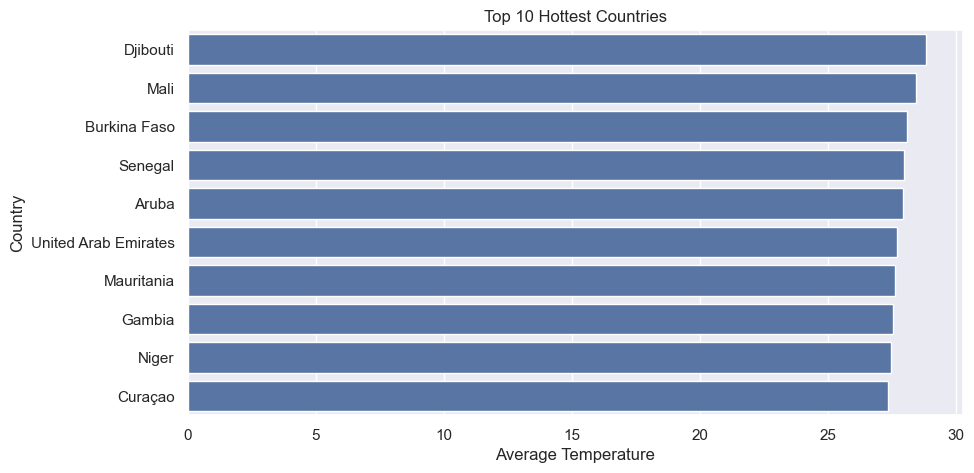

In [29]:
plt.figure(figsize=(10,5))
sns.barplot(x=mean_temp.head(10).values, y=mean_temp.head(10).index)
plt.title('Top 10 Hottest Countries')
plt.xlabel('Average Temperature')
plt.ylabel('Country')
plt.show()

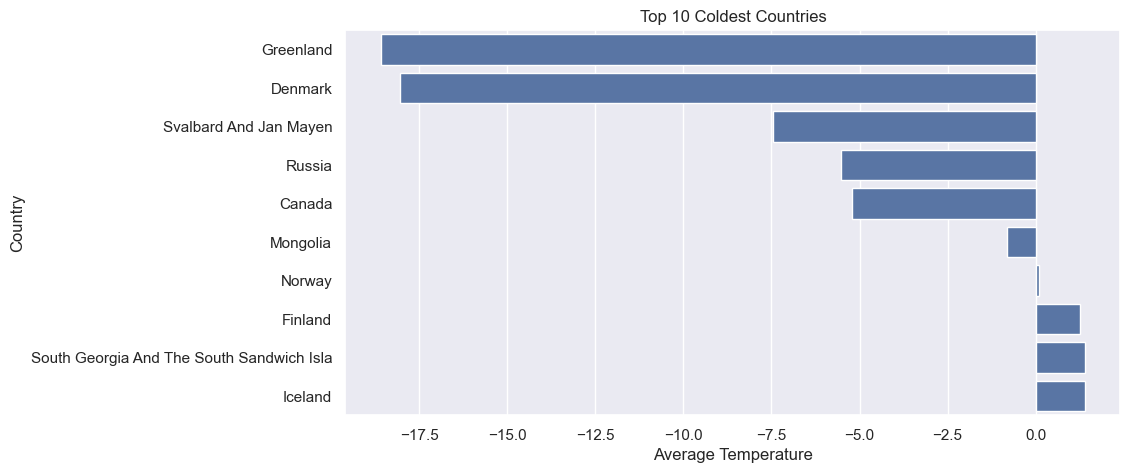

In [30]:
plt.figure(figsize=(10,5))
sns.barplot(x=min_mean_temp.head(10).values, y=min_mean_temp.head(10).index)
plt.title('Top 10 Coldest Countries')
plt.xlabel('Average Temperature')
plt.ylabel('Country')
plt.show()

## 💡 Insight — Country-wise Temperature Analysis

Analyzing average temperatures across all countries reveals clear 
geographical patterns in global temperature distribution.

### 🔥 Top 10 Hottest Countries
- **Djibouti** leads with an average of **28.8°C** — located in the 
Horn of Africa, one of the hottest regions on Earth
- All top 10 hottest countries are in **Africa and the Middle East** — 
reflecting their proximity to the equator and desert climates
- **Nepal** sits at a moderate **14.8°C** — reflecting its diverse 
geography from tropical Terai plains to the freezing Himalayas 🇳🇵

### ❄️ Top 10 Coldest Countries
- **Greenland** is the coldest country at **-18.6°C** on average
- **Denmark, Russia and Canada** follow — all located in the 
**Arctic and Sub-Arctic regions**
- Cold countries are predominantly in the **northern hemisphere** — 
where landmass extends deep into polar regions

**💡 Key Takeaway:** Global temperature distribution is primarily 
driven by **latitude and geography** — countries closer to the equator 
are hottest while those near the poles are coldest. Nepal's moderate 
average reflects its unique Himalayan geography.

## 🌡️ Analysis 6: Countries Warming The Fastest
> Which countries have seen the greatest temperature rise over time?

We compare average temperatures between two periods:
- **Historical period (1900–1950)** — before major industrialization
- **Recent period (2000–2015)** — modern era of high emissions

The difference between these two periods reveals which countries 
have warmed the most due to climate change.

In [31]:
recent_temp = temp_country[(temp_country['year'] >=2000) & (temp_country['year'] <=2015)]
print(recent_temp)

               dt  AverageTemperature  AverageTemperatureUncertainty  \
3074   2000-01-01               0.197                          0.407   
3075   2000-02-01              -0.023                          0.399   
3076   2000-03-01               0.615                          0.429   
3077   2000-04-01               4.124                          0.348   
3078   2000-05-01               8.557                          0.447   
...           ...                 ...                            ...   
577456 2013-04-01              21.142                          0.495   
577457 2013-05-01              19.059                          1.022   
577458 2013-06-01              17.613                          0.473   
577459 2013-07-01              17.000                          0.453   
577460 2013-08-01              19.759                          0.717   

         Country  year  
3074       Åland  2000  
3075       Åland  2000  
3076       Åland  2000  
3077       Åland  2000  
3078      

In [32]:
recent_temp_mean = recent_temp.groupby('Country')['AverageTemperature'].mean()
print(recent_temp_mean)

Country
Afghanistan       15.402963
Africa            24.930043
Albania           13.630128
Algeria           24.291585
American Samoa    27.254415
                    ...    
Western Sahara    23.448287
Yemen             27.295726
Zambia            21.884506
Zimbabwe          21.637963
Åland              6.615567
Name: AverageTemperature, Length: 242, dtype: float64


In [33]:
past_temp = temp_country[(temp_country['year'] >=1900) & (temp_country['year'] <=1950)]
past_temp_mean = past_temp.groupby('Country')['AverageTemperature'].mean()
print(past_temp_mean)

Country
Afghanistan       13.848699
Africa            24.001966
Albania           12.699703
Algeria           22.964209
American Samoa    26.455016
                    ...    
Western Sahara    22.298752
Yemen             26.036379
Zambia            21.150242
Zimbabwe          20.995961
Åland              5.469462
Name: AverageTemperature, Length: 242, dtype: float64


In [34]:
temp_change= recent_temp_mean - past_temp_mean
temp_change = temp_change.sort_values(ascending=False)
temp_change.head(10)

Country
Turkmenistan                           1.822264
Kazakhstan                             1.796404
Uzbekistan                             1.780482
Iran                                   1.750981
French Southern And Antarctic Lands    1.668580
Azerbaijan                             1.656044
Mongolia                               1.641087
Heard Island And Mcdonald Islands      1.603162
Ukraine                                1.602905
United Arab Emirates                   1.602112
Name: AverageTemperature, dtype: float64

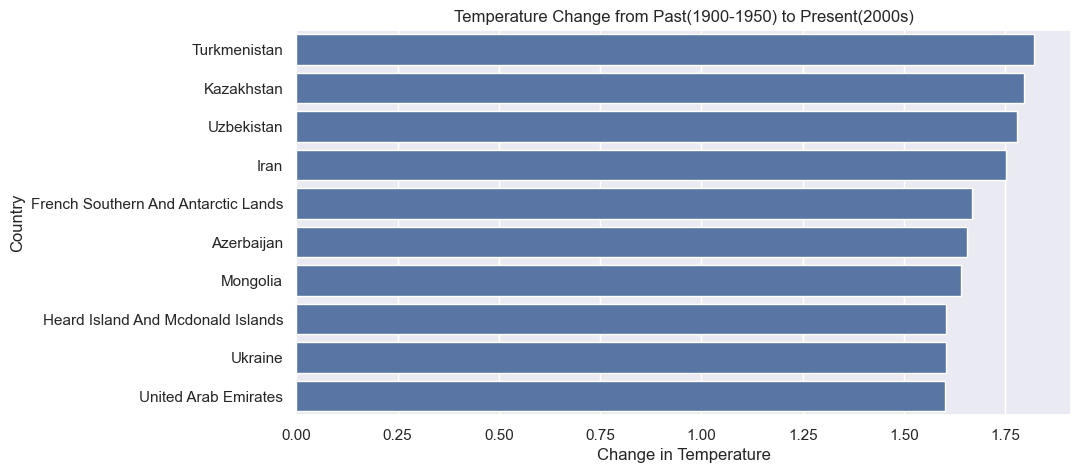

In [35]:
plt.figure(figsize=(10,5))
sns.barplot(x=temp_change.head(10).values, y=temp_change.head(10).index)
plt.title('Temperature Change from Past(1900-1950) to Present(2000s)')
plt.xlabel('Change in Temperature')
plt.ylabel('Country')
plt.show()

## 📊 Analysis 6: Decade-wise Temperature Comparison
> How did each decade compare to the previous in terms of average temperature?

We group data by decade to understand:
- How much did temperatures rise decade by decade?
- Which decade saw the biggest temperature jump?
- Is the rate of warming accelerating over time?

In [36]:
climate_data['decade'] = (climate_data['year'] // 10) *10
decade_temp = climate_data.groupby('decade')['LandAverageTemperature'].mean()
print(decade_temp)

decade
1750    8.172340
1760    7.981625
1770    8.400108
1780    8.141392
1790    8.336867
1800    8.298142
1810    7.251067
1820    8.182233
1830    7.737700
1840    7.978100
1850    8.064883
1860    8.104767
1870    8.276967
1880    8.046775
1890    8.150417
1900    8.257475
1910    8.280850
1920    8.492667
1930    8.641675
1940    8.725417
1950    8.620833
1960    8.633125
1970    8.658400
1980    8.911492
1990    9.155183
2000    9.493892
2010    9.622431
Name: LandAverageTemperature, dtype: float64


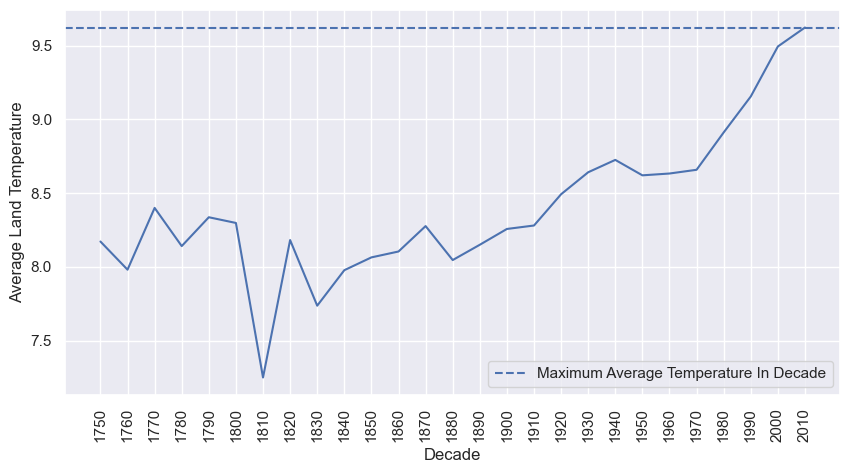

In [37]:
plt.figure(figsize=(10,5))
sns.lineplot(x=decade_temp.index, y=decade_temp.values)
plt.axhline(y=decade_temp.max(), linestyle='--', label='Maximum Average Temperature In Decade')
plt.xticks(decade_temp.index, rotation=90)
plt.xlabel('Decade')
plt.ylabel('Average Land Temperature')
plt.legend()
plt.show()

## 💡 Insight — Decade-wise Temperature Comparison

Analyzing average land temperatures grouped by decade from 
**1750 to 2015** reveals the long term warming trend clearly.

- 📉 A sharp temperature **drop around 1810** — caused by the 
**Mount Tambora volcanic eruption** which blocked sunlight globally,
creating the famous "Year Without a Summer"
- 📈 Temperatures show a **steady rise from 1910 onwards** — 
accelerating significantly after 1980
- 🔥 The **2010s is the hottest decade** in recorded history — 
reaching the highest average land temperature ever measured
- 🚀 The rate of warming has **accelerated dramatically** in recent 
decades compared to earlier centuries

**💡 Key Takeaway:** While temperatures fluctuated naturally for 
centuries, the accelerating rise from 1910 onwards — and especially 
post-1980 — clearly reflects the impact of human industrial activity 
on global climate.

## 🤖 Machine Learning: Temperature Prediction
> Can we predict future global temperatures based on historical data?

We build a **Linear Regression model** using Scikit-learn to:
- Train on historical temperature data
- Predict future temperatures
- Evaluate model accuracy

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [50]:
yearly_temp_recent = yearly_temp[yearly_temp.index >= 1950]
X = yearly_temp_recent.index.values.reshape(-1,1)
Y = yearly_temp_recent.values

In [51]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [52]:
print(X_train.shape)
print(X_test.shape)

(52, 1)
(14, 1)


In [53]:
model = LinearRegression() #Create an empty model
model.fit(X_train, Y_train) #Train the model on training data
Y_pred = model.predict(X_test) #Predicts temperatures for test years

In [54]:
mean_error = mean_absolute_error(Y_test, Y_pred)
r2=r2_score(Y_test, Y_pred)
print(f"Mean Absolute Error: {mean_error:.2f}°C")
print(f"R² Score: {r2:.2f}")

Mean Absolute Error: 0.12°C
R² Score: 0.87


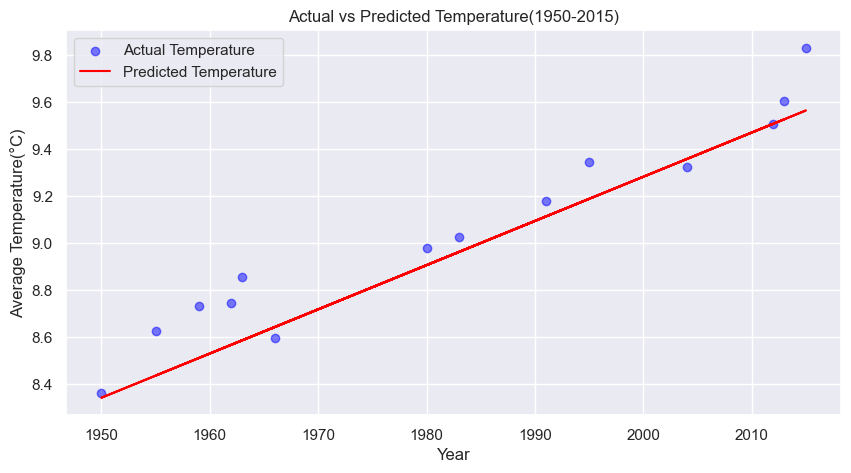

In [55]:
plt.figure(figsize=(10,5))
plt.scatter(X_test, Y_test, color='blue', label='Actual Temperature', alpha=0.5)
plt.plot(X_test, Y_pred, color='red', label='Predicted Temperature')
plt.title('Actual vs Predicted Temperature(1950-2015)')
plt.xlabel('Year')
plt.ylabel('Average Temperature(°C)')
plt.legend()
plt.show()

In [57]:
future_years=[[2025],[2030],[2040],[2050]]
future_prediction = model.predict(future_years)
for year, temp in zip(future_years, future_prediction):
    print(f"Predicted temperature in {year[0]}:{temp:.2f}°C")

Predicted temperature in 2025:9.75°C
Predicted temperature in 2030:9.85°C
Predicted temperature in 2040:10.03°C
Predicted temperature in 2050:10.22°C


## 🤖 Machine Learning: Temperature Prediction Results

Using **Linear Regression** trained on yearly average temperatures 
from **1950-2015**, we built a model to predict future global temperatures.

### 📊 Model Performance
- **Mean Absolute Error:** 0.12°C — predictions are off by only 0.12°C on average
- **R² Score:** 0.87 — model explains 87% of the temperature pattern

### 🔮 Future Temperature Predictions
| Year | Predicted Temperature |
|------|----------------------|
| 2025 | 9.75°C |
| 2030 | 9.85°C |
| 2040 | 10.03°C |
| 2050 | 10.22°C |

### ⚠️ Model Limitations
This is a simple Linear Regression using year as the only feature. 
Real climate models use hundreds of variables like CO2 levels, ocean 
currents, and solar activity. These predictions are **indicative, 
not definitive.**

**💡 Key Takeaway:** Based on historical warming trends, global average 
land temperature is predicted to **cross 10°C by 2040** — highlighting 
the urgent need for climate action worldwide.